In [1]:
import os
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langgraph.checkpoint.memory import InMemorySaver # is kind of checkpointer; with help of this we can implement persistance
# and it saves state final and intermediate values in ram or memory ;; like after shut down everything will gone so we use this one for 
# learning other wise we use database eg ; postgre , redis these all have checkpoints 

c:\LangGraph_CompushX\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm= HuggingFaceEndpoint(
  repo_id="mistralai/Mistral-7B-Instruct-v0.2",
  task="chat-completions",
  huggingfacehub_api_token= os.getenv("HUGGINGFACEHUB_API_TOKEN")
)

model= ChatHuggingFace(llm=llm)


In [3]:
class JokeExpState(TypedDict):
  topic:str
  joke: str 
  explanation: str 


In [4]:


# first node which will generate a joke 

def genJoke(state:JokeExpState):

  prompt= PromptTemplate(
    template="Generate a joke on topic : {topic}",
    input_variables=['joke']
  )
  parser= StrOutputParser()


  chain= prompt|model|parser

  result= chain.invoke(state)
  print(result)

  return {"joke":result}

def genExp(state:JokeExpState):

  prompt= PromptTemplate(
    template="Want a explainatin of a joke : {joke}.\n which is on the topic of {topic}",
    input_variables=['joke', 'topic']
  )

  parser= StrOutputParser()


  chain= prompt| model| parser

  exp= chain.invoke(state)
  print(exp)

  return {"explanation":exp}

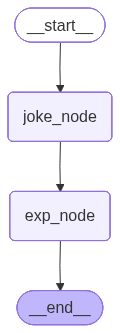

In [5]:
graph= StateGraph(JokeExpState)


graph.add_node('joke_node', genJoke)
graph.add_node("exp_node", genExp)

graph.add_edge(START, 'joke_node')
graph.add_edge('joke_node', 'exp_node')
graph.add_edge('exp_node', END)

# in order to make sure our workflow will perform persistance we build a checkpointer object

checkpointer= InMemorySaver()
# it just say that we want to save each values of state at each checkpointer in memory


jokeWorkflow= graph.compile(checkpointer=checkpointer)
jokeWorkflow

In [7]:
initial_state= {'topic':"pizza."}

config1= {"configurable":{"thread_id":1}}


result_state= jokeWorkflow.invoke(initial_state, config=config1)

Why did the tomato turn red? Because it saw the pizza sauce being made!
This joke is a play on words, specifically the meaning of the word "see." In the joke, the tomato is said to have "seen" the pizza sauce being made. However, in reality, tomatoes cannot see.

The punchline of the joke is unexpected because it uses the figurative meaning of the word "see" rather than the literal meaning.

In summary, the joke "Why did the tomato turn red?" "Because it saw the pizza sauce being made!" is a play on words that uses the unexpected figurative meaning of the word "see."


In [ ]:
result_state

{'topic': 'indian poblic.',
 'joke': 'Why don\'t some members of the Indian public go to the doctor when they\'re sick?\n\nBecause they think "Aap ki medic, humein aapki saath denge" - which translates to "Your medicine, we will be with your medicine"!\n\nBut remember folks, humor is subjective and this joke is meant to bring a smile to your face! Enjoy!',
 'explanation': 'This joke is making fun of a common belief or misconception within the Indian public. The punchline of the joke, "Your medicine, we will be with your medicine," is a mistranslation or misinterpretation of the phrase "Aap ki medic, humein aapki saath denge," which literally means "Your medicine, we will be with you in your medicine."\n\nThe joke is poking fun at the idea that some members of the Indian public might misunderstand or misinterpret the phrase "Aap ki medic, humein aapki saath denge," and think that it means that they should be with someone\'s medicine, rather than with the person who is taking the medicin

In [ ]:
## Now we can see what being stored in memory againest thread_id 1
# so using get_state we can fetch final state values
print(f"final state values: {jokeWorkflow.get_state(config=config1)}")


# if we want see all saved values (history)

print(f"\n\nall saved state values: {list(jokeWorkflow.get_state_history(config=config1))}")
# it will give four values bz
# first value for **before START**
# second value for **before node1**
# third value for **before node2**
# four value for **before END** ; 
# which node we are gonna use this will also show that 

# so we store things before checkpointer come

final state values: StateSnapshot(values={'topic': 'pizza.', 'joke': 'Why did the tomato turn red? Because it saw the pizza sauce being made!', 'explanation': 'This joke is a play on words, specifically the meaning of the word "see." In the joke, the tomato is said to have "seen" the pizza sauce being made. However, in reality, tomatoes cannot see.\n\nThe punchline of the joke is unexpected because it uses the figurative meaning of the word "see" rather than the literal meaning.\n\nIn summary, the joke "Why did the tomato turn red?" "Because it saw the pizza sauce being made!" is a play on words that uses the unexpected figurative meaning of the word "see."'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137473-444b-69e4-8002-d88935c86bb2'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-13T14:43:58.432087+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137473

In [12]:
list(jokeWorkflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'pizza.', 'joke': 'Why did the tomato turn red? Because it saw the pizza sauce being made!', 'explanation': 'This joke is a play on words, specifically the meaning of the word "see." In the joke, the tomato is said to have "seen" the pizza sauce being made. However, in reality, tomatoes cannot see.\n\nThe punchline of the joke is unexpected because it uses the figurative meaning of the word "see" rather than the literal meaning.\n\nIn summary, the joke "Why did the tomato turn red?" "Because it saw the pizza sauce being made!" is a play on words that uses the unexpected figurative meaning of the word "see."'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137473-444b-69e4-8002-d88935c86bb2'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-13T14:43:58.432087+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f137473-11d5-65d0-8001-5cc

In [15]:
## now try to change thread_id

config2= {"configurable":{"thread_id":"2"}}

result2= jokeWorkflow.invoke({"topic":"pasta"}, config=config2)

Why don't pasta make good secret keepers? Because they alwaysletting things slip! (Spaghetti and slippery are the puns here)
Sure thing! This joke plays on the double meaning of the word "pasta." In one sense, pasta is a type of food made from wheat flour and water. In another sense, pasta can also mean a large number or quantity of something.

The punchline of the joke is "Because they always let things slip!" Here, "pasta" is being used metaphorically to refer to people who cannot keep secrets. The joke is playing on the double meaning of the word "pasta," and using the pun "spaghetti and slippery" to add an extra layer of humor to the joke.


In [16]:
result2

{'topic': 'pasta',
 'joke': "Why don't pasta make good secret keepers? Because they alwaysletting things slip! (Spaghetti and slippery are the puns here)",
 'explanation': 'Sure thing! This joke plays on the double meaning of the word "pasta." In one sense, pasta is a type of food made from wheat flour and water. In another sense, pasta can also mean a large number or quantity of something.\n\nThe punchline of the joke is "Because they always let things slip!" Here, "pasta" is being used metaphorically to refer to people who cannot keep secrets. The joke is playing on the double meaning of the word "pasta," and using the pun "spaghetti and slippery" to add an extra layer of humor to the joke.'}

In [17]:
jokeWorkflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': "Why don't pasta make good secret keepers? Because they alwaysletting things slip! (Spaghetti and slippery are the puns here)", 'explanation': 'Sure thing! This joke plays on the double meaning of the word "pasta." In one sense, pasta is a type of food made from wheat flour and water. In another sense, pasta can also mean a large number or quantity of something.\n\nThe punchline of the joke is "Because they always let things slip!" Here, "pasta" is being used metaphorically to refer to people who cannot keep secrets. The joke is playing on the double meaning of the word "pasta," and using the pun "spaghetti and slippery" to add an extra layer of humor to the joke.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f13749c-d345-6e28-8006-ee7ed9c96708'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-04-13T15:02:34.009731+00:00', parent_config={'configurable': {'thread_id

In [ ]:
list(jokeWorkflow.get_state_history(config2)) # bz 8 values bz i ron 2 times

[StateSnapshot(values={'topic': 'pasta', 'joke': "Why don't pasta make good secret keepers? Because they alwaysletting things slip! (Spaghetti and slippery are the puns here)", 'explanation': 'Sure thing! This joke plays on the double meaning of the word "pasta." In one sense, pasta is a type of food made from wheat flour and water. In another sense, pasta can also mean a large number or quantity of something.\n\nThe punchline of the joke is "Because they always let things slip!" Here, "pasta" is being used metaphorically to refer to people who cannot keep secrets. The joke is playing on the double meaning of the word "pasta," and using the pun "spaghetti and slippery" to add an extra layer of humor to the joke.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f13749c-d345-6e28-8006-ee7ed9c96708'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-04-13T15:02:34.009731+00:00', parent_config={'configurable': {'thread_i

## You can see both conversation are stored in memory but at different thread

* so you can see at any time we can resume any value of that thread wheater it is intermediate or final value